In [ ]:
url1 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32023R2631" #only modified by block
url2 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=consil:ST_13940_2023_ADD_2_REV_1" #no modifies or modified by block
url3 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32019R2019" #both modifies or modified by block

In [2]:
from graph_builder import GraphBuilder

In [3]:
# it takes 30s to 1 minutes
graph_data = GraphBuilder("https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32023R2631")
modifiedby_data_list = graph_data.attributes_list
modifies_data_links = graph_data.modifies_attributes_list # should be [] in url1

In [ ]:
G1 = graph_data.create_graph() # modifiedby graph 

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

def graph(G):
    """
    Visualize the graph 
    """

    pos = nx.spring_layout(G, seed=50)
    edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_nodes(G, pos, node_size=10)
    nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")
    nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True,
                        arrowsize=20, connectionstyle="arc3,rad=0.1")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Directed Graph with Attributes")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


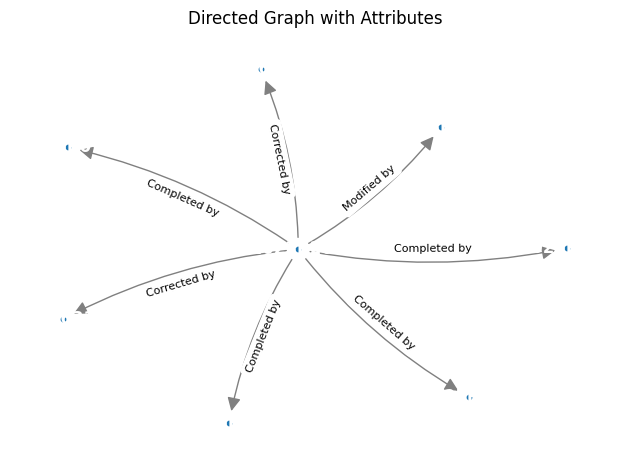

In [14]:
graph(G1);

In [ ]:
def build_full_graph2(start_url):
    
    G = nx.DiGraph()
    visited = set()
    seen = {start_url}  # track queued URLs to prevent duplicates
    queue = deque([start_url])
    
    while queue:
        url = queue.popleft()# to remove and return the first element (the "leftmost" item) from a collections.deque object.

        if url in visited: # to avoid repeatedly visiting the same website
            continue
        else:
            visited.add(url)
        
        G_init = GraphBuilder(url)
        G_sub = G_init.create_graph()
        if G_sub is not None and len(G_sub.nodes) > 0:
            G = nx.compose(G, G_sub)

        i = 0
        links = G_init.find_links()
        for link in links:
            i += 1
            if link not in visited and link not in seen:  # check both sets
                seen.add(link)   # mark as seen before appending
                queue.append(link)
                print(link, i)
    print(seen)
    return G

In [ ]:
newgraph = build_full_graph2(url1)

In [ ]:
def collect_all_urls(start_url):
    visited = set() # tuple that stores all links
    seen = {start_url} #set element, no duplicates
    queue = deque([(start_url, 0)])  # the BFS queue. Stores tuples of (url, layer). Starts with start_url at layer 0
    all_urls = [] 

    while queue:
        url, layer = queue.popleft() # Remove the leftmost item from the queue and unpack the tuple into two variables — the URL and its layer number.

        if url in visited:
            continue # skip everything below, don't add to all_urls,  all_urls has no duplicates
        visited.add(url) 
        all_urls.append(url) # only unique URLs reach here

        print(f"[Layer {layer}] Visiting: {url}") #shows which layer is currently on and which URL is being visited.

        #links = GraphBuilder(url).find_links()
        #new_links = [link for link in links if link not in seen] #Filters out already-seen links using a list comprehension — only keeps links that haven't been queued before

        links = set(GraphBuilder(url).find_links())
        new_links = [link for link in links if link not in seen]

        print(f"  --> Found {len(new_links)} new links at layer {layer + 1}") #shows how many new links were found, and labels them as belonging to the next layer

        for link in new_links:
            seen.add(link)
            queue.append((link, layer + 1))  # next layer
            print(f"      Queued [{layer + 1}]: {link}")

    print(f"\nTotal URLs collected: {len(all_urls)}") 
    #Once the queue is empty and the loop ends — print the total count and return the full list of visited URLs.
    return all_urls

In [ ]:
all_links = collect_all_urls(url1)